In [201]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)

In [202]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print(housing.feature_names)
print(X.shape)
print(y.shape)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
(20640, 8)
(20640,)


In [203]:
print("Features:\n", X[0])
print("\nTarget:", y[0])

Features:
 [   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]

Target: 4.526


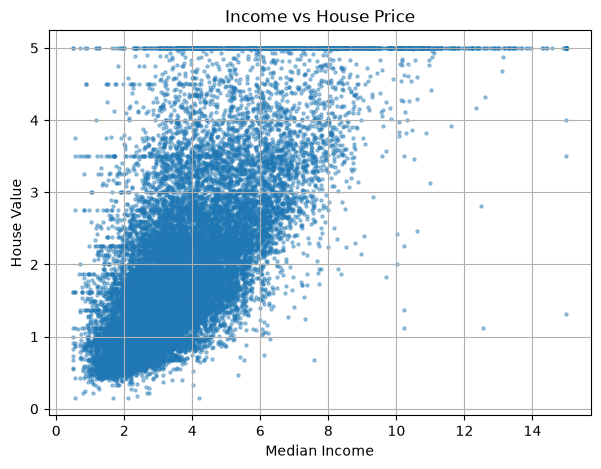

In [204]:
plt.figure(figsize=(7,5))

plt.scatter(
    X[:,0],
    y,
    s=5,
    alpha=0.4
)

plt.xlabel("Median Income")
plt.ylabel("House Value")

plt.title("Income vs House Price")

plt.grid(True)
plt.show()

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size =0.2,random_state= 42)

print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


In [206]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

In [207]:
X_train = torch.tensor(X_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)

y_test = torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

In [208]:
class LinearModel(nn.Module):

    def __init__(self, input_dim, hidden_size, output_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_dim)

    def forward(self, x):

        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)

        return x

In [209]:
model = LinearModel(input_dim= 8 ,hidden_size= 32, output_dim= 1)

loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [210]:
epochs = 500

loss_history = []

for epoch in range(epochs):

    # Forward
    predictions = model(X_train)

    # Loss
    loss = loss_fn(predictions, y_train)

    # Backprop
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch} | Loss: {loss.item():.4f}"
        )

Epoch 0 | Loss: 6.2949
Epoch 50 | Loss: 4.0225
Epoch 100 | Loss: 2.2250
Epoch 150 | Loss: 1.1558
Epoch 200 | Loss: 0.8593
Epoch 250 | Loss: 0.7771
Epoch 300 | Loss: 0.7173
Epoch 350 | Loss: 0.6667
Epoch 400 | Loss: 0.6244
Epoch 450 | Loss: 0.5874


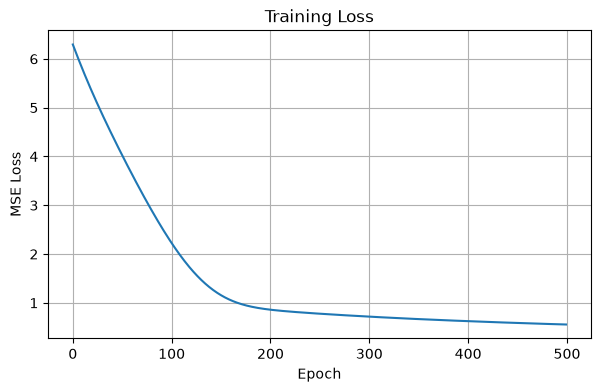

In [211]:
plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.grid(True)
plt.show()

In [212]:
with torch.no_grad():

    test_predictions = model(X_test)

    test_loss = loss_fn(
        test_predictions,
        y_test
    )

print(f"Test MSE: {test_loss.item():.4f}")

Test MSE: 0.5806


In [213]:
rmse = torch.sqrt(test_loss)

print(f"RMSE: {rmse.item():.4f}")

RMSE: 0.7619


In [214]:
print(y_test.shape)
print(test_predictions.shape)

torch.Size([4128, 1])
torch.Size([4128, 1])


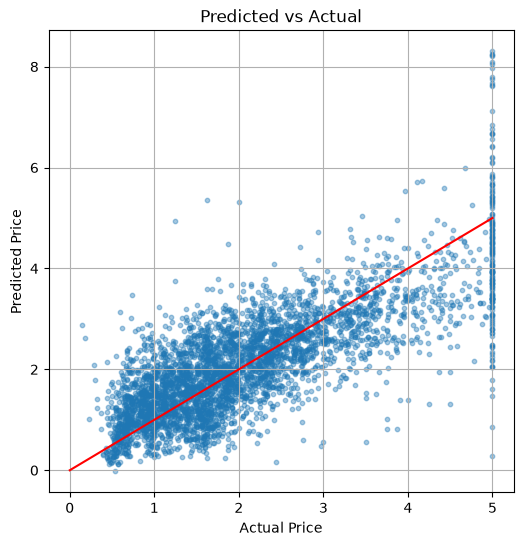

In [215]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test.numpy(),
    test_predictions.numpy(),
    alpha=0.4,
    s=10
)

plt.plot(
    [0,5],
    [0,5],
    color="red"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Predicted vs Actual")

plt.grid(True)
plt.show()

In [216]:
with torch.no_grad():
    ss_res = torch.sum((y_test - test_predictions) ** 2)
    ss_tot = torch.sum((y_test - y_test.mean()) ** 2)

    r2 = 1 - (ss_res / ss_tot)

print(f"R² Score: {r2:.4f}")

R² Score: 0.5570
